# Example: Gradient-based optimisation of a flux-mediated iSWAP gate between two transmons

In [1]:
import itertools

import matplotlib.pyplot as plt

import numpy as np

from cthree.model.GeneratorDrive import GeneratorDrive
from cthree.propagation.Propagation import Propagation
from cthree.signal.Device import CosTone
from cthree.signal.SimpleGenerator import CosGenerator

np.set_printoptions(linewidth=400)

from cthree.OptimisationMap import OptimisationMap
from cthree.Quantity import Quantity
from cthree.measurement.UnitaryFidelity import UnitaryFidelity
from cthree.model.Coupling import Coupling
from cthree.optimisers.ScipyOptimiserGradient import ScipyOptimiserGradient
from cthree.propagation.ScipyExpmGOAT import ScipyExpmGOAT

from cthree.model.ClosedModel import ClosedModel
from cthree.model.CompositeHamiltonian import CompositeHamiltonian
from cthree.model.Transmon import Transmon

The sytem consists of two coupled transmons with three levels each. We fix the transmon frequency and anharmonicity to values that don't have any unwanted frequency collisions. The coupling strength is fixed as well. These parameters have to be specified as Quantites with a range, but we will not pass them to the optimised in order to keep them fixed. Additionally, the first transmon is driven at the frequency of the second one. 

In [2]:
tone = CosTone()
#tone.amplitude = Quantity(100e6, 50e6, 200e6)
#tone.frequency = Quantity(5.8e9, 5.7e9, 5.9e9)
print(tone.getParameters())
generator = CosGenerator(devices=[tone])
drive = GeneratorDrive(generator, isLongitudinal=False)

transmon1 = Transmon(
    dimension=2,
    frequency=Quantity(5.8e9, 5.7e9, 5.9e9, "Hz", "Transmon 1 frequency"),
    anharmonicity=Quantity(-200e6, -210e6, -190e6, "Hz", "Transmon 1 anharmonicity"),
    drives=[drive]
)
transmon2 = Transmon(
    dimension=2,
    frequency=Quantity(6.0e9, 5.9e9, 6.1e9, "Hz", "Transmon 2 frequency"),
    anharmonicity=Quantity(-200e6, -210e6, -190e6, "Hz", "Transmon 2 anharmonicity")
)
coupling = Coupling(
    {transmon1, transmon2},
    isLongitudinal=False,
    coefficient=Quantity(50e6, 40e6, 60e6, "Hz", "Coupling strength")
)
hamiltonian = CompositeHamiltonian([transmon1, transmon2], [coupling])

[Amplitude: 1.26 MHz , Frequency: 31.4 GHz , Phase: 0 rad ]


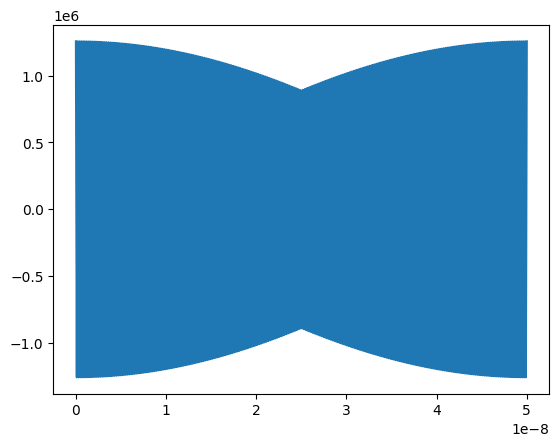

In [3]:
t_final = 50e-9
times = np.linspace(0, t_final, 1000)
signal = generator.generateSignal(times)

plt.figure()
plt.plot(times, signal)
plt.show()

We check the eigenvalues to make sure that there is no resonance while idling.

In [4]:
matrix = hamiltonian.getMatrixOneTime(0.0)
evals = np.linalg.eigvalsh(matrix)
print("Energies in GHz: ", np.round(evals / 1e6) / 1e3)
transitions = evals[1:] - evals[:-1]
print("Transition energies in GHz: ", np.round(transitions / 1e3) / 1e6)
matrix

Energies in GHz:  [-0.     5.788  6.012 11.8  ]
Transition energies in GHz:  [5.788409 0.223606 5.788409]


Array([[0.00000000e+00, 0.00000000e+00, 1.25663706e+06, 5.00000000e+07],
       [0.00000000e+00, 6.00000000e+09, 5.00000000e+07, 1.25663706e+06],
       [1.25663706e+06, 5.00000000e+07, 5.80000000e+09, 0.00000000e+00],
       [5.00000000e+07, 1.25663706e+06, 0.00000000e+00, 1.18000000e+10]], dtype=float64)

We select a propagation method, piecewise constant exponentation, and configure iSWAP as a target gate. Also we initialize the full basis at time 0 with $\mathbb{I}_4$ in order to compute the full propagator.

In [6]:
model = ClosedModel(hamiltonian)
prop = ScipyExpmGOAT(model, res=100e9)

iSwapGate = np.array(
    [[1.0, 0, 0, 0],
     [0, 1.0, 0, 0],
     [0, 0, 0, 1.0],
     [0, 0, 1.0, 0]]
)  

prop.setInitialState(np.identity(4))
gateFid = UnitaryFidelity(
    propagation=prop,
    gate=iSwapGate,
    times=np.array([0.0, t_final]),
)
gateFid.measure()

0.19074639359836748

In [ ]:
def plotPopulation(propagation: Propagation):
    basis1 = [i for i in range(transmon1.dimension())]
    basis2 = [i for i in range(transmon2.dimension())]
    labels = [f"{i},{j}" for (i, j) in itertools.product(basis1, basis2)]
    
    signal = generator.generateSignal(times)
    states = propagation.propagate(times)

    fig, ax = plt.subplots(2, figsize=(8, 6), sharex=True)
    ax[0].plot(times / 1e-9, signal)
    ax[0].set_xlabel("Time [ns]")
    ax[0].set_ylabel("Signal [Hz]")
    
    ax[1].plot(times/1e-9, np.abs(states)[:,:,0] ** 2, label=labels)
    ax[1].set_xlabel("Time [ns]")
    ax[1].set_ylabel("Population")
    ax[1].legend()
    
    plt.show()

plotPopulation(prop)

We define an optimizer and link our fidelity measure as a goal function. The only optimisable parameter is the frequency of transmon 1.

In [7]:
optmap = OptimisationMap()
optmap.add(drive)
print(optmap)

opt = ScipyOptimiserGradient(gateFid, optimisables=optmap)

==== <class 'cthree.model.GeneratorDrive.GeneratorDrive'> ====
[Amplitude: 1.26 MHz , Frequency: 31.4 GHz , Phase: 0 rad ]




In [9]:
opt.optimise()

KeyboardInterrupt: 